In [3]:
from Charts.ploTools import *
from Charts.resumeTools import *
from glob import glob

In [83]:
experiments = glob('OptimizeIterationsResults/*')
experiments

['OptimizeIterationsResults\\OptunaDDPGExp',
 'OptimizeIterationsResults\\OptunaDDPGExp0001',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_CorrelationPunishment05',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_CorrelationPunishment07',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_RewardNetProfit',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_RewardNetProfit_ShuffleDaysTrue',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_RMemorySize10',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_RMemorySize3',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_RMemorySize3_NetProfit',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_ShuffleDaysTrue',
 'OptimizeIterationsResults\\OptunaDDPGExpBase_Total']

In [78]:
glob('OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3/*/*/metrics_resume.pkl')

['OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\000000\\2024-11-09_18-37-02_133\\metrics_resume.pkl',
 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\000001\\2024-11-09_18-59-33_320\\metrics_resume.pkl',
 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\0000010\\2024-11-09_23-25-02_349\\metrics_resume.pkl',
 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\0000011\\2024-11-09_23-54-52_114\\metrics_resume.pkl',
 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\0000012\\2024-11-10_00-17-34_265\\metrics_resume.pkl',
 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\0000013\\2024-11-10_00-39-26_267\\metrics_resume.pkl',
 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\0000014\\2024-11-10_01-01-17_870\\metrics_resume.pkl',
 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\0000015\\2024-11-10_01-23-17_299\\metrics_resume.pkl',
 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\0000016\\2024-11-10_01

In [79]:
path_metrics_resume = 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\000000\\2024-11-09_18-37-02_133\\metrics_resume.pkl'
path_metrics_resume_testing = 'OptimizeIterationsResults/OptunaDDPGExpBase_RMemorySize3\\000000\\2024-11-09_18-37-02_133\\metrics_resume_testing.pkl'


In [80]:
PREFIX_EXP = "OptimizeIterationsResults/OptunaDDPGExpBase_Total/00000*/*"

In [147]:
PATH_DATA_LIST_TRAINING_REWARDS_RESUME = glob(PREFIX_EXP + "/metrics_resume_testing.pkl")
testing_rewards_resume_avg = mean_resume_data(PATH_DATA_LIST_TRAINING_REWARDS_RESUME)

In [82]:
testing_rewards_resume_avg

{'DDPG Agent': {'net_worths_delta': [1475.9795036995033,
   -1051.0349013879,
   -1279.7719375059833,
   2191.981680932903,
   -284.1384734103993,
   -681.881862296288,
   -506.9923729434944,
   -872.3106271438976,
   -186.69960614439114,
   -743.0841999919919,
   749.8969828640144,
   1225.9140513236116,
   393.97648880220294,
   5772.208712061072,
   -36.37694778559642,
   -586.0441958051964,
   -1091.2121818833848,
   222.22832019510753,
   1277.0205744338173,
   -170.7186627388971,
   555.6877417930012,
   -3789.7239621937993,
   -62.43421624249793,
   -403.4563731458264,
   -544.567151355378,
   -903.120800396615,
   652.3938575892264,
   9.53203406020766,
   1268.2057859602762,
   -8590.548791057572,
   5069.375647694321,
   -1176.6821755767546,
   3017.0040212219055,
   1136.7494165596945,
   -1574.9071403096889,
   441.06489062971264,
   -353.9416285445006,
   -279.3478729675933,
   -730.5664535053958,
   -704.6354979774966,
   -528.5466344712033,
   470.4065838385079,
   3449.

In [148]:
testing_rewards_resume_avg ['DDPG Agent'].keys()

dict_keys(['net_worths_delta', 'pearson_correlations', 'rewards', 'portfolio_returns', 'stds', 'sharpe_ratios', 'net_worths', 'net_worths_delta_acum', 'rewards_acum', 'dates'])

In [137]:
def plotTestRewardsMeanSTD(FolderName,ExpName, lastN=50, save=False, agentName='DDPG Agent'): 
    # Example :
    # FolderName = OptunaDDPGExpBase_ShuffleDaysTrue
    # ExpName = DDPG Días Aleatorios

    PREFIX_EXP = f"OptimizeIterationsResults\\{FolderName}/00000*/*" 
    PATH_DATA_LIST_TESTING_REWARDS_RESUME = glob(PREFIX_EXP + "/metrics_resume_testing.pkl")
    testing_rewards_resume_avg = mean_resume_data(PATH_DATA_LIST_TESTING_REWARDS_RESUME)[agentName]
    mean = np.array(testing_rewards_resume_avg['portfolio_returns'])
    std = np.array(testing_rewards_resume_avg['stds'])
    #norm_mean = np.mean(rewards)
    #norm_var = np.var(rewards)
    #epsilon = 1e-8

    #mean = (rewards - norm_mean) / np.sqrt(norm_var + epsilon)
    #mean = np.mean(rewards)

    fig, ax = plt.subplots()
    # Plot the mean and std
    ax.plot(mean, label='Media', color='blue')
    ax.fill_between(range(len(mean)), mean - std, mean + std, color='blue', alpha=0.2, label='Desviación Estándar')
    # Add title and labels
    ax.set_title(f'Media y Desviación Estándar Recompensas - {ExpName}')
    ax.set_xlabel('Lote', fontsize=14)
    ax.set_ylabel('Recompensa', fontsize=14)
    # Set the axis values to font size 12
    ax.tick_params(axis='both', which='major', labelsize=12)
    plt.grid(axis='y')
    # Add a legend
    ax.legend()
    # Show the plot
    if save:
        if agentName == 'DDPG Agent':
            plt.savefig(f"AAAAAMeanSTD_{ExpName.replace(' ','_')}.png", dpi=300, bbox_inches='tight')
        elif agentName == 'SP500 Agent':
            plt.savefig(f"AAAAAMeanSTD_SP500_Agent.png", dpi=300, bbox_inches='tight')
    plt.show()

    return np.array(mean[-lastN:]).mean(), np.array(std[-lastN:]).mean()

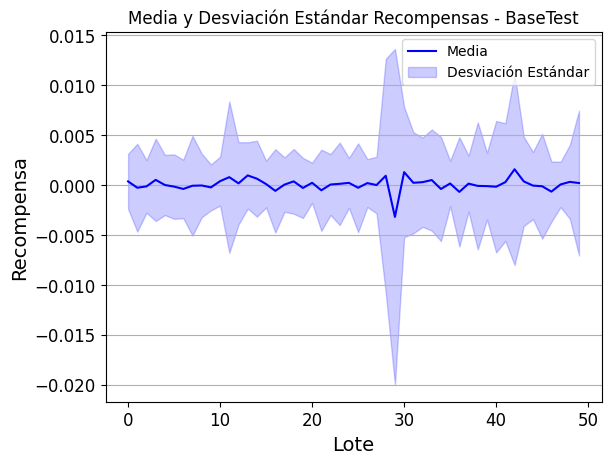

(6.301422854509519e-05, 0.004448940840141971)

In [142]:
mean , std = plotTestRewardsMeanSTD('OptunaDDPGExpBase_RMemorySize3', 'BaseTest', lastN=50, save=False, agentName='DDPG Agent')
mean , std

In [139]:
mean , std

(6.301422854509519e-05, 0.004448940840141971)

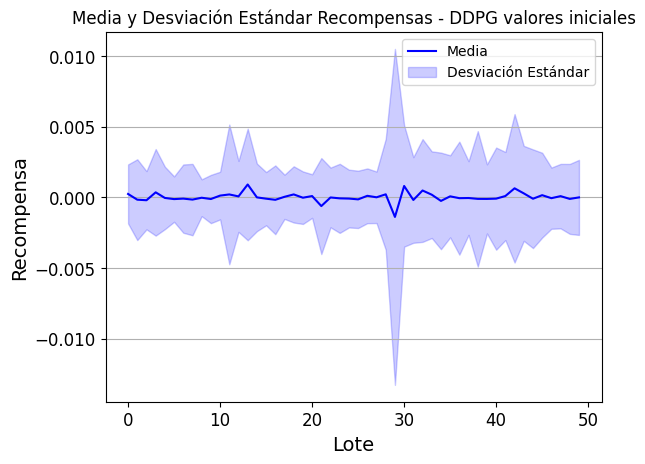

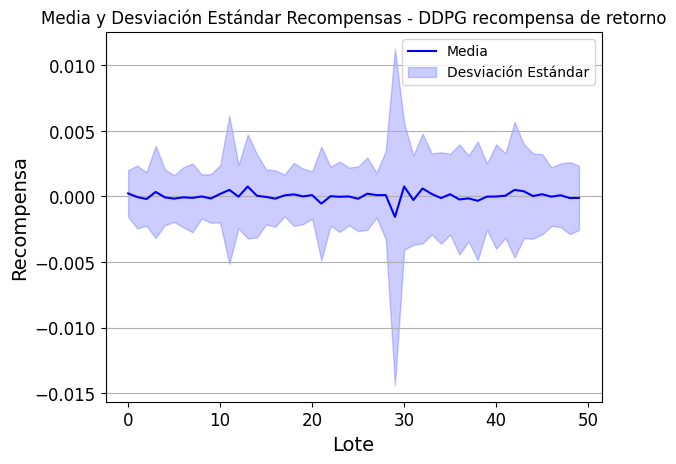

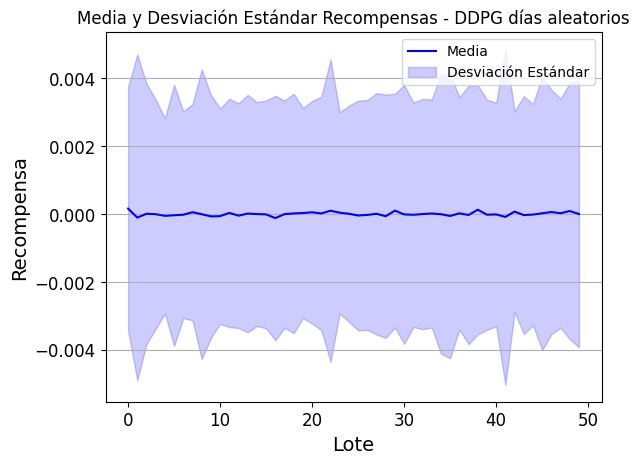

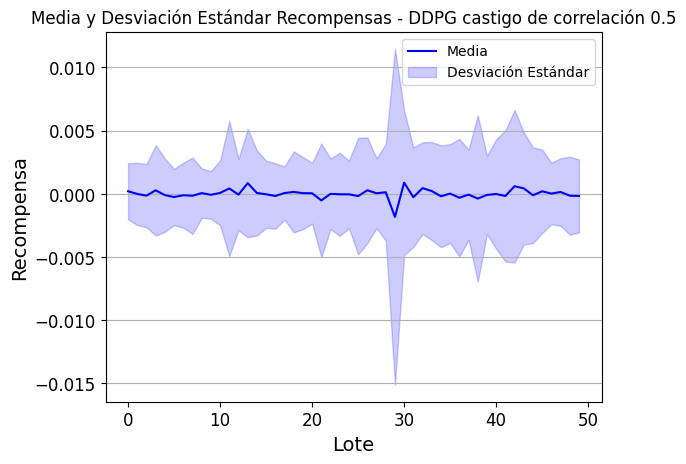

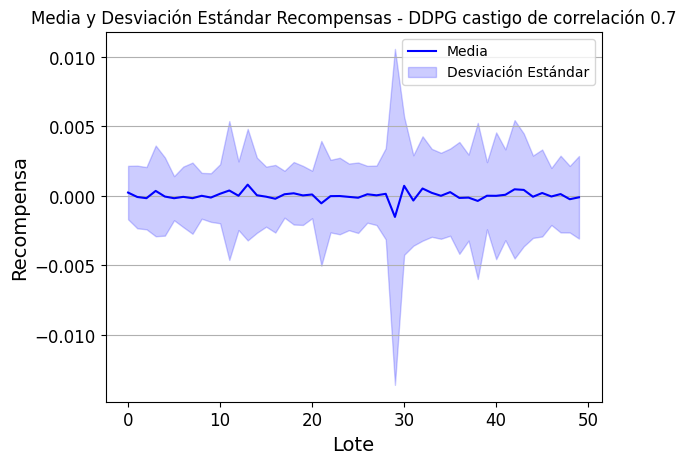

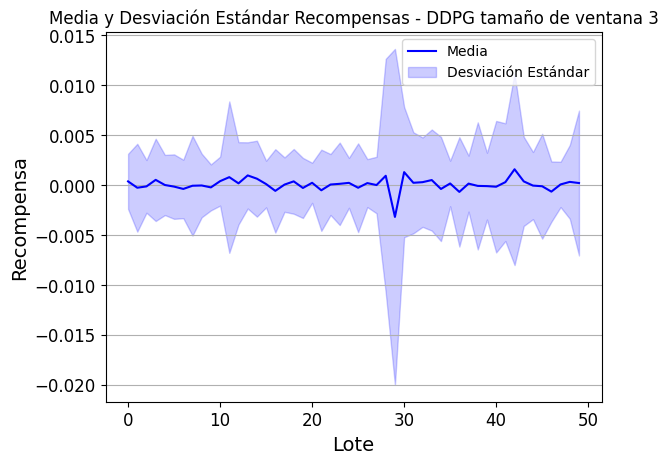

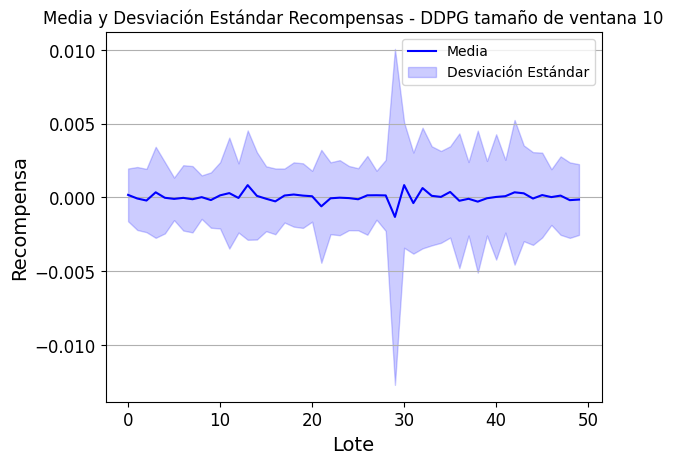

,ExpName,Mean,Std
0,DDPG valores iniciales,0.000014,0.002918
1,DDPG recompensa de retorno,0.000018,0.003100
2,DDPG días aleatorios,0.000002,0.003561
3,DDPG castigo de correlación 0.5,-0.000002,0.003653
4,DDPG castigo de correlación 0.7,0.000019,0.003096
5,DDPG tamaño de ventana 3,0.000063,0.004449
6,DDPG tamaño de ventana 10,0.000025,0.002912


In [143]:
results = []
for key in list(lastDict.keys()):
    FolderName = key
    ExpName = lastDict[key]
    meanCalculated, stdCalculated = plotTestRewardsMeanSTD(FolderName,ExpName, 50, False)
    results.append([ExpName, meanCalculated, stdCalculated])

df_port_f = pd.DataFrame(results, columns=['ExpName', 'Mean', 'Std'])
df_port_f

In [118]:
FolderName = 'OptunaDDPGExpBase_ShuffleDaysTrue'
ExpName = 'BaseTest'
lastN = 50
save = False
agentName = 'DDPG Agent'

In [149]:
testing_rewards_resume_avg ['DDPG Agent'].keys()

dict_keys(['net_worths_delta', 'pearson_correlations', 'rewards', 'portfolio_returns', 'stds', 'sharpe_ratios', 'net_worths', 'net_worths_delta_acum', 'rewards_acum', 'dates'])

In [ ]:
net_worths_delta

In [152]:
metrica = 'net_worths_delta_acum'
def getNormalizeRewardsMeanSTD(FolderName, ExpName, lastN=50, save=False, agentName='DDPG Agent'):
    PREFIX_EXP = f"OptimizeIterationsResults\\{FolderName}/00000*/*" 
    PATH_DATA_LIST_TESTING_REWARDS_RESUME = glob(PREFIX_EXP + "/metrics_resume_testing.pkl")
    testing_rewards_resume_avg = mean_resume_data(PATH_DATA_LIST_TESTING_REWARDS_RESUME)[agentName]
    rewards = np.array(testing_rewards_resume_avg[metrica])
    #norm_mean = np.mean(rewards)
    #norm_var = np.var(rewards)
    #epsilon = 1e-8
    #norm_rewards = (rewards - norm_mean) / np.sqrt(norm_var + epsilon)
    mean = np.mean(rewards)
    std = np.std(rewards)

  #  print(f"Mean: {mean}, Std: {std}")
    return mean , std

lastDict = {
'OptunaDDPGExpBase_Total' : 'DDPG valores iniciales',
'OptunaDDPGExpBase_RewardNetProfit' : 'DDPG recompensa de retorno',
'OptunaDDPGExpBase_ShuffleDaysTrue' : 'DDPG días aleatorios',
'OptunaDDPGExpBase_CorrelationPunishment05' : 'DDPG castigo de correlación 0.5',
'OptunaDDPGExpBase_CorrelationPunishment07' : 'DDPG castigo de correlación 0.7',
'OptunaDDPGExpBase_RMemorySize3' : 'DDPG tamaño de ventana 3',
'OptunaDDPGExpBase_RMemorySize10' : 'DDPG tamaño de ventana 10'}

results = []
for key in list(lastDict.keys()):
    FolderName = key
    ExpName = lastDict[key]
    meanCalculated, stdCalculated = getNormalizeRewardsMeanSTD(FolderName,ExpName, 50, False)
    results.append([ExpName, meanCalculated, stdCalculated])

df = pd.DataFrame(results, columns=['ExpName', 'Mean', 'Std'])
df

,ExpName,Mean,Std
0,DDPG valores iniciales,101204.252745,2641.323178
1,DDPG recompensa de retorno,102555.097843,2982.321114
2,DDPG días aleatorios,98272.110504,900.510116
3,DDPG castigo de correlación 0.5,99904.642461,3756.835310
4,DDPG castigo de correlación 0.7,102627.031985,2963.180211
5,DDPG tamaño de ventana 3,108694.808352,6250.078847
6,DDPG tamaño de ventana 10,103687.508874,2890.284204


In [131]:
lastDict = {
'OptunaDDPGExpBase_Total' : 'DDPG valores iniciales',
'OptunaDDPGExpBase_RewardNetProfit' : 'DDPG recompensa de retorno',
'OptunaDDPGExpBase_ShuffleDaysTrue' : 'DDPG días aleatorios',
'OptunaDDPGExpBase_CorrelationPunishment05' : 'DDPG castigo de correlación 0.5',
'OptunaDDPGExpBase_CorrelationPunishment07' : 'DDPG castigo de correlación 0.7',
'OptunaDDPGExpBase_RMemorySize3' : 'DDPG tamaño de ventana 3',
'OptunaDDPGExpBase_RMemorySize10' : 'DDPG tamaño de ventana 10'}

Mean: 73.71943530047801, Std: 2005.908892236116
Mean: 99.98467713922801, Std: 2096.9273771397034
Mean: -34.52624684995814, Std: 337.0228482916542
Mean: -24.710053175280322, Std: 2295.948368527667
Mean: 104.84507395028506, Std: 2061.1773062831326
Mean: 360.79422481026035, Std: 3832.3751702309
Mean: 144.26232640962684, Std: 2013.2298874401133


,ExpName,Mean,Std
0,DDPG valores iniciales,73.719435,2005.908892
1,DDPG recompensa de retorno,99.984677,2096.927377
2,DDPG días aleatorios,-34.526247,337.022848
3,DDPG castigo de correlación 0.5,-24.710053,2295.948369
4,DDPG castigo de correlación 0.7,104.845074,2061.177306
5,DDPG tamaño de ventana 3,360.794225,3832.375170
6,DDPG tamaño de ventana 10,144.262326,2013.229887


# Test 111

# Estudio the test train networth acum

In [1]:
from Charts.ploTools import *
from Charts.resumeTools import *
from glob import glob

In [2]:
lastDict = {
'OptunaDDPGExpBase_Total' : 'DDPG valores iniciales',
'OptunaDDPGExpBase_RewardNetProfit' : 'DDPG recompensa de retorno',
'OptunaDDPGExpBase_ShuffleDaysTrue' : 'DDPG días aleatorios',
'OptunaDDPGExpBase_CorrelationPunishment05' : 'DDPG castigo de correlación 0.5',
'OptunaDDPGExpBase_CorrelationPunishment07' : 'DDPG castigo de correlación 0.7',
'OptunaDDPGExpBase_RMemorySize3' : 'DDPG tamaño de ventana 3',
'OptunaDDPGExpBase_RMemorySize10' : 'DDPG tamaño de ventana 10'}

In [3]:
FolderName = 'OptunaDDPGExpBase_RMemorySize3'
ExpName = 'BaseTest'
PREFIX_EXP = f"OptimizeIterationsResults/{FolderName}/00000*/*"
PATH_DATA_LIST_TRAINING_REWARDS_RESUME = glob(PREFIX_EXP + "/metrics_resume_testing.pkl")

net_worths


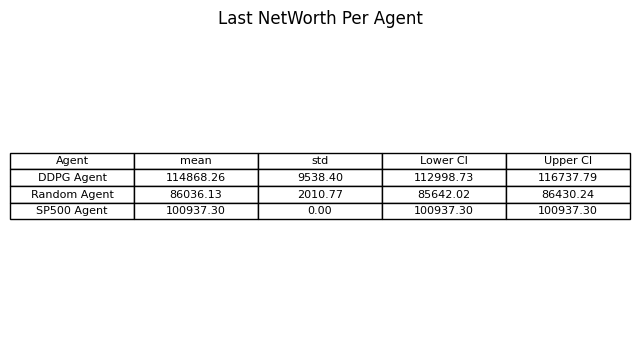

In [5]:
a , b = plotTableFullLastWorthMultiAgents(PATH_DATA_LIST_TRAINING_REWARDS_RESUME, show=False, agent_name='DDPG Agent')

In [15]:
source = 'train'

net_worths
net_worths
net_worths
net_worths
net_worths
net_worths
net_worths


,ExpName,Mean,Std
0,DDPG valores iniciales,106103.0,16586.0
1,DDPG recompensa de retorno,103322.0,15512.0
2,DDPG días aleatorios,95721.0,20836.0
3,DDPG castigo de correlación 0.5,101294.0,17017.0
4,DDPG castigo de correlación 0.7,100381.0,15719.0
5,DDPG tamaño de ventana 3,100114.0,5629.0
6,DDPG tamaño de ventana 10,110332.0,24098.0


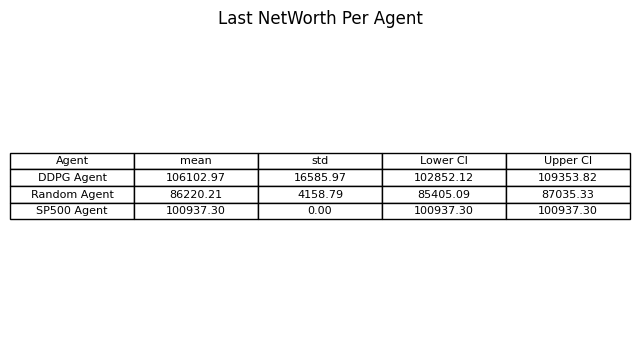

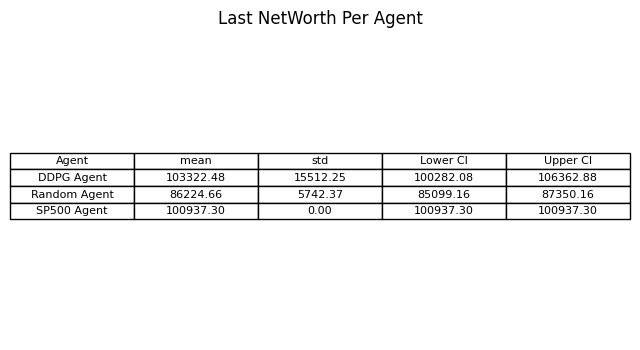

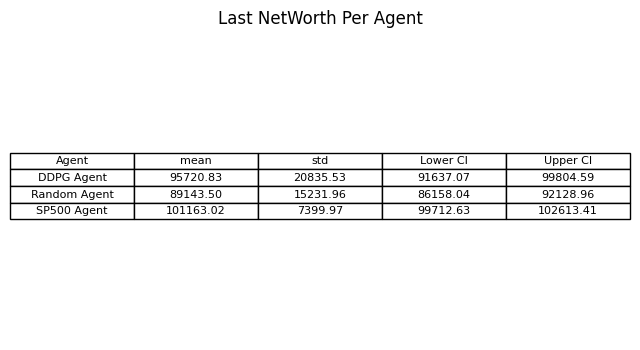

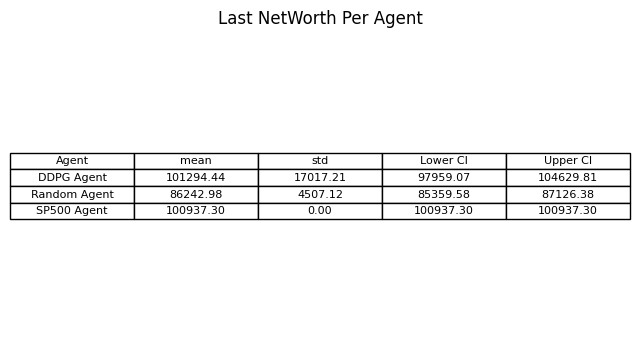

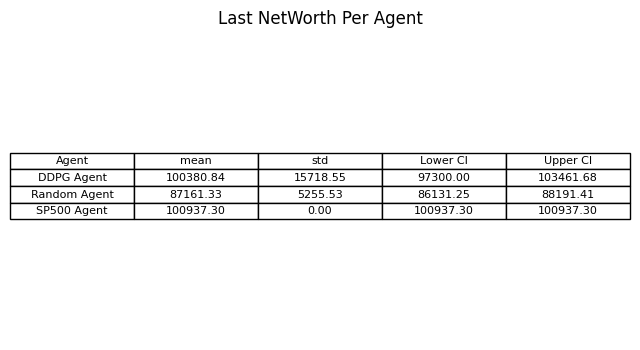

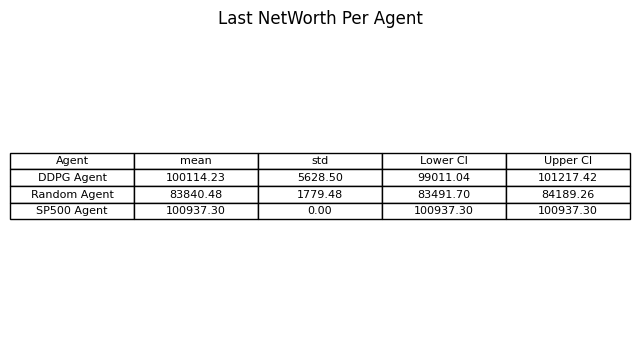

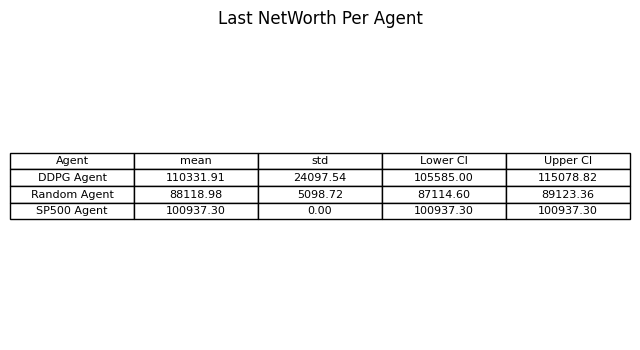

In [16]:
results = []
for key in list(lastDict.keys()):
    FolderName = key
    ExpName = lastDict[key]
    PREFIX_EXP = f"OptimizeIterationsResults\\{FolderName}/00000*/*" 
    if source == 'test':
        PATH_DATA_LIST_TRAINING_REWARDS_RESUME = glob(PREFIX_EXP + "/metrics_resume_testing.pkl")
    elif source == 'train':
        PATH_DATA_LIST_TRAINING_REWARDS_RESUME = glob(PREFIX_EXP + "/metrics_resume.pkl")
    meanCalculated, stdCalculated = plotTableFullLastWorthMultiAgents(PATH_DATA_LIST_TRAINING_REWARDS_RESUME, show=False, agent_name='DDPG Agent')
    results.append([ExpName, meanCalculated, stdCalculated])
df = pd.DataFrame(results, columns=['ExpName', 'Mean', 'Std'])
df[['Mean', 'Std']] = df[['Mean', 'Std']].round(0)
df